Shuvam Chowdhury 
Lab 4

Q 1


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

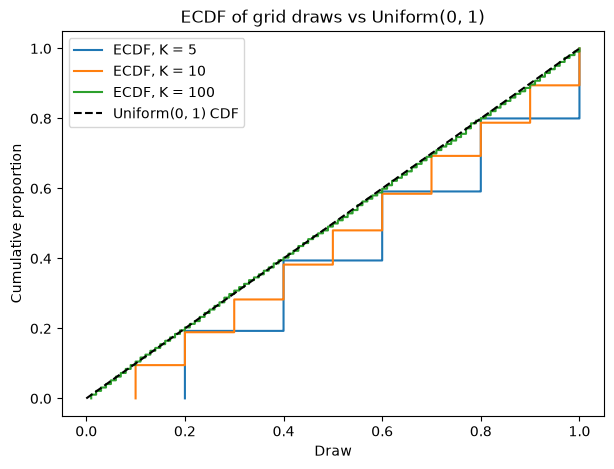

In [4]:
rng = np.random.default_rng(5030)
n = 5_000

fig, ax = plt.subplots(figsize=(7, 5))
for K in [5, 10, 100]:
    grid = np.arange(1, K + 1) / K           # 1/K, 2/K, ..., K/K
    draws = rng.choice(grid, size=n)         # For equal probability
    x = np.sort(draws)
    y = np.arange(1, n + 1) / n
    ax.step(x, y, where="post", label=f"ECDF, K = {K}")

xs = np.linspace(0, 1, 200)
ax.plot(xs, uniform.cdf(xs, loc=0, scale=1), "k--", label="Uniform(0, 1) CDF")
ax.set_xlabel("Draw")
ax.set_ylabel("Cumulative proportion")
ax.set_title("ECDF of grid draws vs Uniform(0, 1)")
ax.legend()
plt.show()


Answer 1: As K increases the draws approach a Uniform(0, 1) distribution. In the "ECDF of grid draws vs Uniform(0, 1)" plot, the K = 5 ECDF is a coarse staircase with five jumps of about 0.2 each at 0.2, 0.4, 0.6, 0.8, and 1, and the K = 10 ECDF has ten smaller steps of about 0.1. By K = 100 the ECDF lies almost exactly on the dashed Uniform(0, 1) CDF, which is the straight line F(x) = x. This happens because every grid point has probability 1/K, so the proportion of draws at or below x gets close to x as the grid gets finer.

From the distributions in the table, this simulation generates the Uniform CDF with lower a = 0 and upper b = 1.


Q 3


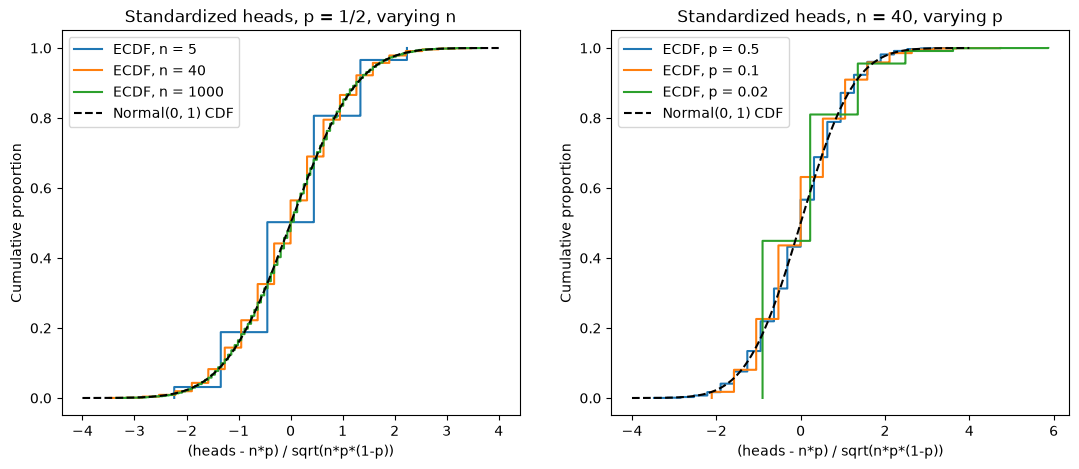

In [7]:
from scipy.stats import norm

b = 5_000
zs = np.linspace(-4, 4, 400)

def one_experiment(n, p):
    coins = rng.random(n) < p                       # flip n coins
    heads = coins.sum()                             # count of heads
    centered = heads - n * p                        # subtract expected heads
    return centered / np.sqrt(n * p * (1 - p))      # divide by standard deviation

def repeat_experiment(n, p, b):
    results = np.empty(b)
    for i in range(b):                              # repeat b times
        results[i] = one_experiment(n, p)
    return results

def plot_ecdf(ax, data, label):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where="post", label=label)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: p = 1/2, increasing n
for n in [5, 40, 1000]:
    plot_ecdf(axes[0], repeat_experiment(n, 0.5, b), f"ECDF, n = {n}")
axes[0].plot(zs, norm.cdf(zs, loc=0, scale=1), "k--", label="Normal(0, 1) CDF")
axes[0].set_title("Standardized heads, p = 1/2, varying n")

# Right plot: n = 40, varying p
for p in [0.5, 0.1, 0.02]:
    plot_ecdf(axes[1], repeat_experiment(40, p, b), f"ECDF, p = {p}")
axes[1].plot(zs, norm.cdf(zs, loc=0, scale=1), "k--", label="Normal(0, 1) CDF")
axes[1].set_title("Standardized heads, n = 40, varying p")

for ax in axes:
    ax.set_xlabel("(heads - n*p) / sqrt(n*p*(1-p))")
    ax.set_ylabel("Cumulative proportion")
    ax.legend()
plt.show()


Answer 3: As n increases, the standardized number of heads approaches a Normal(0, 1) distribution. norm.cdf(x, loc=0, scale=1). In the "Standardized heads, p = 1/2, varying n" plot, the n = 5 ECDF is a coarse staircase with only a few large jumps, the n = 40 ECDF has many small steps that closely follow the dashed Normal(0, 1) CDF, and the n = 1000 ECDF lies almost exactly on it. The steps shrink because the standardized count can only take n + 1 possible values so a larger n gives a finer grid of outcomes centered at 0 with standard deviation 1.

Moving p away from 1/2 slows the approach to the Normal because the count of heads becomes skewed when heads are rare. In the "Standardized heads, n = 40, varying p" plot, p = 0.5 closely follows the dashed Normal(0, 1) CDF and p = 0.1 is still close but blockier. With p = 0.02 the ECDF jumps to about 0.45 at around -0.9 (the zero-heads outcome), has only a few large steps, and stretches out to about 6 on the right far beyond where the Normal CDF reaches 1. So for a fixed n = 40 the further p is from 1/2 the worse the Normal approximation.


Q 4


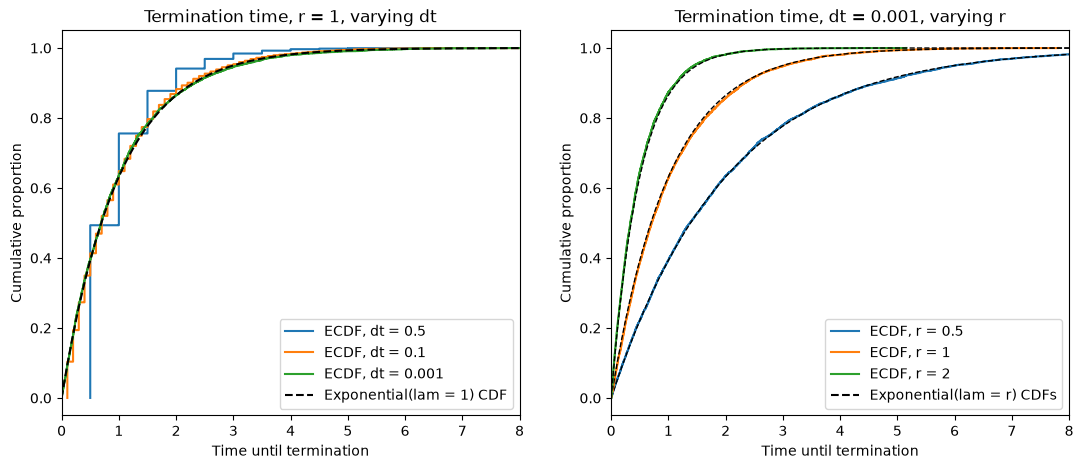

In [ ]:
from scipy.stats import expon

n = 5_000

def one_process(r, dt):
    period = 1
    while rng.random() >= r * dt:        # each period terminates with prob r*dt
        period += 1                      
    return period * dt                   # convert period to time

def repeat_process(r, dt, n):
    times = np.empty(n)
    for i in range(n):                   #repeat n times
        times[i] = one_process(r, dt)
    return times

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ts = np.linspace(0, 8, 400)

# Left plot: r = 1, shrinking dt
for dt in [0.5, 0.1, 1e-3]:
    plot_ecdf(axes[0], repeat_process(1, dt, n), f"ECDF, dt = {dt}")
axes[0].plot(ts, expon.cdf(ts, scale=1/1), "k--", label="Exponential(lam = 1) CDF")
axes[0].set_title("Termination time, r = 1, varying dt")

# Right plot: dt = 1e-3, varying r
for r in [0.5, 1, 2]:
    plot_ecdf(axes[1], repeat_process(r, 1e-3, n), f"ECDF, r = {r}")
    axes[1].plot(ts, expon.cdf(ts, scale=1/r), "k--", linewidth=1)
axes[1].plot([], [], "k--", label="Exponential(lam = r) CDFs")
axes[1].set_title("Termination time, dt = 0.001, varying r")

for ax in axes:
    ax.set_xlim(0, 8)
    ax.set_xlabel("Time until termination")
    ax.set_ylabel("Cumulative proportion")
    ax.legend()
plt.show()


Answer 4: As dt goes to zero, the termination time approaches an Exponential distribution with rate lam = r. expon.cdf(x, scale=1/r). In the "Termination time, r = 1, varying dt" plot the dt = 0.5 ECDF is a coarse staircase that can only jump at multiples of 0.5, with its first jump to about 0.5 at t = 0.5, while the dt = 0.1 ECDF has much finer steps that track the dashed curve. At dt = 0.001 the ECDF lies almost exactly on the dashed Exponential(lam = 1) CDF, because the discrete periods become so short that termination can happen at essentially any time.

Changing r changes how quickly termination happens but not the shape of the distribution. In the "Termination time, dt = 0.001, varying r" plot, each ECDF lies on its own dashed Exponential(lam = r) CDF and a larger r makes the curve rise faster. With r = 2 almost all processes have terminated by about t = 2, with r = 1 by about t = 4 to 5, and with r = 0.5 the ECDF is still just below 1 at t = 8, so a higher termination rate means shorter times.


Q 6


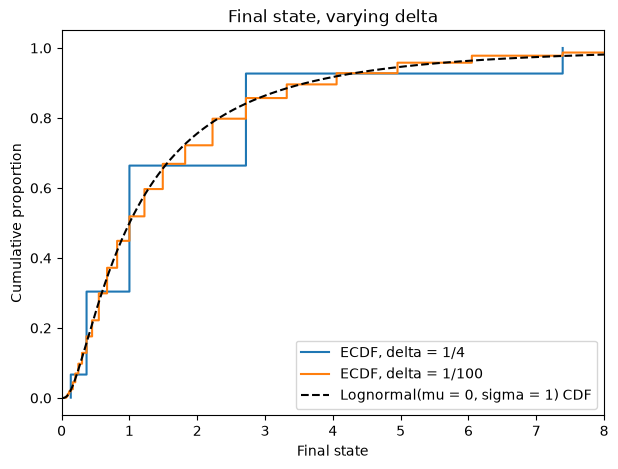

In [11]:
from scipy.stats import lognorm

B = 1_000

def one_path(delta):
    state = 1.0                                  # start at 1
    u = np.exp(np.sqrt(delta))                   # up factor
    d = np.exp(-np.sqrt(delta))                  # down factor
    steps = round(1 / delta)                     # 1/delta small time steps
    for step in range(steps):                    
        if rng.random() < 0.5:                   
            state *= u
        else:                                    
            state *= d
    return state

def repeat_path(delta, B):
    finals = np.empty(B)
    for i in range(B):                           # repeat B times #records final position
        finals[i] = one_path(delta)
    return finals

fig, ax = plt.subplots(figsize=(7, 5))
xs6 = np.linspace(0.001, 8, 400)

for delta, name in [(1/4, "1/4"), (1/100, "1/100")]:
    finals = repeat_path(delta, B)
    plot_ecdf(ax, finals, f"ECDF, delta = {name}")

ax.plot(xs6, lognorm.cdf(xs6, s=1, scale=np.exp(0)), "k--", label="Lognormal(mu = 0, sigma = 1) CDF")
ax.set_xlim(0, 8)
ax.set_xlabel("Final state")
ax.set_ylabel("Cumulative proportion")
ax.set_title("Final state, varying delta")
ax.legend()
plt.show()


Answer 6: As delta gets close to zero, the final state approaches a Lognormal distribution with mu = 0 and sigma = 1. lognorm.cdf(x, s=1, scale=np.exp(0)). In the "Final state, varying delta" plot, the delta = 1/4 ECDF is a coarse staircase with only five jumps at about 0.1, 0.4, 1, 2.7, and 7.4, while the delta = 1/100 ECDF has many small steps that closely follow the dashed Lognormal CDF. That curve reaches 0.5 at a final state of about 1 and has a long right tail, still just below 1 at a final state of 8 so the final states are strongly right skewed.
